# Track 2 — Retrieval Quality Analysis

Analyses retrieval metrics from `retrieval_report.json` (computed offline from
`pipeline_report.json`).

Figures produced:
- `fig_03_recall_at_k.png` — Recall@k (k=3,5,10) by Nota and overall
- `fig_04_mrr_distribution.png` — MRR histogram across cases

**Prerequisites:**
1. `make eval-pipeline` (requires services running)
2. `make eval-retrieval`

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("../..").resolve()
RETRIEVAL_REPORT = ROOT / "evaluation" / "results" / "retrieval_report.json"
FIG_DIR = ROOT / "evaluation" / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if not RETRIEVAL_REPORT.exists():
    print(f"retrieval_report.json not found at {RETRIEVAL_REPORT}")
    print("Run 'make eval-pipeline' then 'make eval-retrieval' first.")
    raise SystemExit(0)

with open(RETRIEVAL_REPORT, encoding="utf-8") as f:
    report = json.load(f)

agg = report.get("aggregate", {})
print(f"Report timestamp: {report['timestamp']}")
print(f"Cases evaluated: {agg.get('total_cases')}")
print(f"Recall@3={agg['recall_at_k']['3']:.4f}  @5={agg['recall_at_k']['5']:.4f}  @10={agg['recall_at_k']['10']:.4f}")
print(f"MRR={agg.get('mrr', 0):.4f}")

Report timestamp: 2026-02-25T01:00:35.938796+00:00
Cases evaluated: 37
Recall@3=0.6013  @5=0.7027  @10=0.7568
MRR=0.7568


In [2]:
# Build case-level DataFrame
df = pd.DataFrame(report.get("case_results", []))
df["nota"] = df["case_id"].str[:3]
print(df[["case_id", "nota", "num_chunks", "num_anchors",
          "recall_at_3", "recall_at_5", "recall_at_10", "mrr"]].to_string(index=False))

case_id nota  num_chunks  num_anchors  recall_at_3  recall_at_5  recall_at_10  mrr
N97-001  N97          10            4       0.7500       1.0000           1.0  1.0
N97-002  N97          10            4       0.7500       1.0000           1.0  1.0
N97-003  N97           6            1       1.0000       1.0000           1.0  1.0
N97-004  N97           6            1       1.0000       1.0000           1.0  1.0
N97-005  N97           7            2       1.0000       1.0000           1.0  1.0
N97-006  N97           8            3       1.0000       1.0000           1.0  1.0
N97-007  N97          10            4       0.5000       1.0000           1.0  1.0
N97-008  N97           8            3       1.0000       1.0000           1.0  1.0
N97-009  N97           8            3       1.0000       1.0000           1.0  1.0
N97-010  N97          10            4       0.7500       1.0000           1.0  1.0
N97-011  N97          10            4       0.7500       1.0000           1.0  1.0
N97-

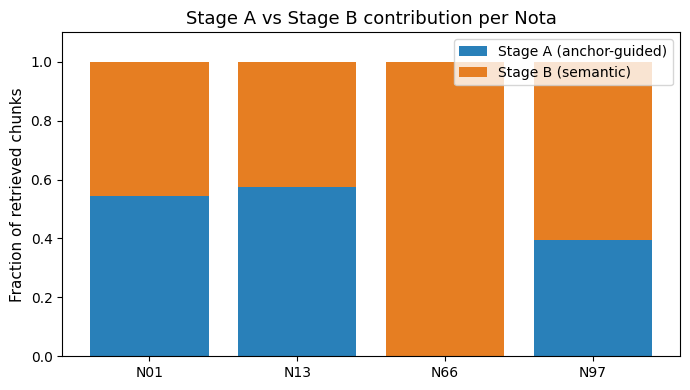

In [3]:
# Cell 3 — Stage A vs B contribution per nota (stacked bar)
stage_df = df.groupby("nota").agg(
    stage_a=("stage_a_fraction", "mean"),
    stage_b=("stage_b_fraction", "mean"),
).reset_index()

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(stage_df))
bars_a = ax.bar(x, stage_df["stage_a"], label="Stage A (anchor-guided)", color="#2980b9")
bars_b = ax.bar(x, stage_df["stage_b"], bottom=stage_df["stage_a"],
                label="Stage B (semantic)", color="#e67e22")
ax.set_xticks(x)
ax.set_xticklabels(stage_df["nota"])
ax.set_ylabel("Fraction of retrieved chunks", fontsize=11)
ax.set_title("Stage A vs Stage B contribution per Nota", fontsize=13)
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
fig.savefig(FIG_DIR / "fig_03_stage_contribution.png", dpi=150)
plt.show()

   nota     R3     R5    R10  cases
    N01 1.0000 1.0000 1.0000      8
    N13 0.5000 0.7500 1.0000      8
    N66 0.0000 0.0000 0.0000      9
    N97 0.8542 1.0000 1.0000     12
OVERALL 0.6013 0.7027 0.7568     37


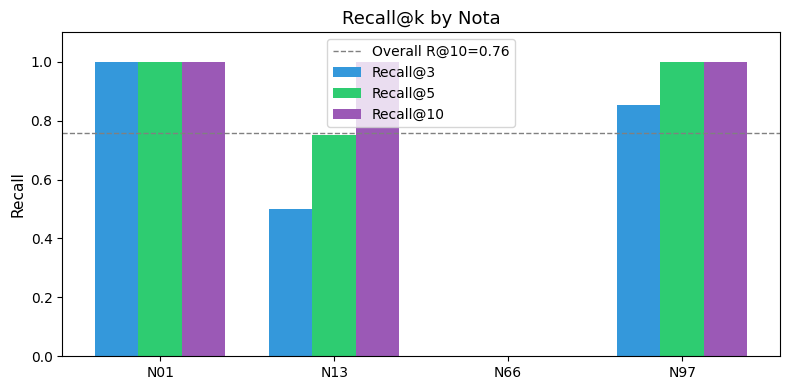

Saved fig_03_recall_at_k.png


In [4]:
# Cell 4 — Recall@k table by nota and overall
recall_by_nota = df.groupby("nota").agg(
    R3=("recall_at_3", "mean"),
    R5=("recall_at_5", "mean"),
    R10=("recall_at_10", "mean"),
    cases=("case_id", "count"),
).round(4).reset_index()

# Add overall row
overall = pd.DataFrame([{
    "nota": "OVERALL",
    "R3":  round(agg["recall_at_k"]["3"], 4),
    "R5":  round(agg["recall_at_k"]["5"], 4),
    "R10": round(agg["recall_at_k"]["10"], 4),
    "cases": agg["total_cases"],
}])
recall_table = pd.concat([recall_by_nota, overall], ignore_index=True)
print(recall_table.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(recall_by_nota))
width = 0.25
ax.bar(x - width, recall_by_nota["R3"],  width, label="Recall@3",  color="#3498db")
ax.bar(x,          recall_by_nota["R5"],  width, label="Recall@5",  color="#2ecc71")
ax.bar(x + width,  recall_by_nota["R10"], width, label="Recall@10", color="#9b59b6")
ax.axhline(y=agg["recall_at_k"]["10"], color="grey", linestyle="--", linewidth=1,
           label=f"Overall R@10={agg['recall_at_k']['10']:.2f}")
ax.set_xticks(x)
ax.set_xticklabels(recall_by_nota["nota"])
ax.set_ylim(0, 1.1)
ax.set_ylabel("Recall", fontsize=11)
ax.set_title("Recall@k by Nota", fontsize=13)
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "fig_03_recall_at_k.png", dpi=150)
plt.show()
print("Saved fig_03_recall_at_k.png")

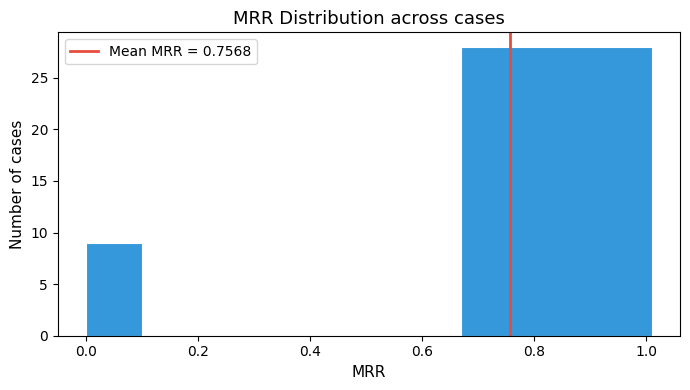

Saved fig_04_mrr_distribution.png


In [5]:
# Cell 5 — MRR distribution histogram
fig, ax = plt.subplots(figsize=(7, 4))
bins = [0, 0.1, 0.2, 0.34, 0.5, 0.67, 1.01]  # 1/10, 1/5, 1/3, 1/2, 2/3, 1
ax.hist(df["mrr"], bins=bins, edgecolor="white", linewidth=0.8, color="#3498db")
ax.axvline(x=agg.get("mrr", 0), color="#e74c3c", linewidth=2,
           label=f"Mean MRR = {agg.get('mrr', 0):.4f}")
ax.set_xlabel("MRR", fontsize=11)
ax.set_ylabel("Number of cases", fontsize=11)
ax.set_title("MRR Distribution across cases", fontsize=13)
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "fig_04_mrr_distribution.png", dpi=150)
plt.show()
print("Saved fig_04_mrr_distribution.png")

In [6]:
# Cell 6 — Per-case retrieval breakdown DataFrame
detail_cols = ["case_id", "nota", "num_chunks", "num_anchors",
               "recall_at_3", "recall_at_5", "recall_at_10",
               "precision_at_3", "precision_at_5", "mrr",
               "stage_a_fraction", "stage_b_fraction"]
display(df[detail_cols].style.format({
    c: "{:.4f}" for c in detail_cols if c not in ["case_id", "nota", "num_chunks", "num_anchors"]
}))

,case_id,nota,num_chunks,num_anchors,recall_at_3,recall_at_5,recall_at_10,precision_at_3,precision_at_5,mrr,stage_a_fraction,stage_b_fraction
0,N97-001,N97,10,4,0.7500,1.0000,1.0000,1.0000,1.0000,1.0000,0.5000,0.5000
1,N97-002,N97,10,4,0.7500,1.0000,1.0000,1.0000,1.0000,1.0000,0.5000,0.5000
2,N97-003,N97,6,1,1.0000,1.0000,1.0000,0.3333,0.2000,1.0000,0.1667,0.8333
3,N97-004,N97,6,1,1.0000,1.0000,1.0000,0.3333,0.2000,1.0000,0.1667,0.8333
4,N97-005,N97,7,2,1.0000,1.0000,1.0000,0.6667,0.4000,1.0000,0.2857,0.7143
5,N97-006,N97,8,3,1.0000,1.0000,1.0000,1.0000,0.6000,1.0000,0.3750,0.6250
6,N97-007,N97,10,4,0.5000,1.0000,1.0000,1.0000,1.0000,1.0000,0.5000,0.5000
7,N97-008,N97,8,3,1.0000,1.0000,1.0000,1.0000,0.6000,1.0000,0.3750,0.6250
8,N97-009,N97,8,3,1.0000,1.0000,1.0000,1.0000,0.6000,1.0000,0.3750,0.6250
9,N97-010,N97,10,4,0.7500,1.0000,1.0000,1.0000,1.0000,1.0000,0.5000,0.5000
